In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
product_sales = pd.read_csv("../content/sales_integrated.csv")

print("Dataset shape:", product_sales.shape)

Dataset shape: (130402, 55)


In [3]:
print(product_sales.head())
print("\nDataset shape:", product_sales.shape)
print("\nColumns:")
print(product_sales.columns.tolist())

       so_id  line_number product_id  quantity  unit_price  gst_rate  \
0  SO-990591            1       P018        19       11300        28   
1  SO-990591            2       P026         2         310        18   
2  SO-990591            3       P026         3         310        18   
3  SO-990591            4       P013         9        1450        18   
4  SO-990591            5       P004         3       39800        28   

   line_total  gst_amount  line_grand_total customer_id  ... pincode region  \
0      214700     60116.0          274816.0       C0070  ...  784913   West   
1         620       111.6             731.6       C0070  ...  784913   West   
2         930       167.4            1097.4       C0070  ...  784913   West   
3       13050      2349.0           15399.0       C0070  ...  784913   West   
4      119400     33432.0          152832.0       C0070  ...  784913   West   

  branch_id_customer credit_limit current_balance  payment_terms_customer  \
0             A

In [4]:
required_columns = [
    "customer_id",
    "customer_type",
    "industry_segment",
    "city",
    "state",
    "region",
    "sales_channel",
    "so_id",
    "quantity",
    "line_total",
    "order_date"
]

missing_columns = [
    col for col in required_columns
    if col not in product_sales.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


In [5]:
week8_data = product_sales.copy()

print("Week 8 dataset shape:", week8_data.shape)

Week 8 dataset shape: (130402, 55)


### **Convert Numeric Columns**

In [6]:
numeric_columns = [
    "quantity",
    "line_total"
]

for col in numeric_columns:
    week8_data[col] = pd.to_numeric(
        week8_data[col],
        errors="coerce"
    )

week8_data[numeric_columns].dtypes

,0
quantity,int64
line_total,int64


### **Convert Order Date**

In [7]:
week8_data["order_date"] = pd.to_datetime(
    week8_data["order_date"],
    errors="coerce"
)

print("Minimum order date:", week8_data["order_date"].min())
print("Maximum order date:", week8_data["order_date"].max())

Minimum order date: 2019-01-01 00:00:00
Maximum order date: 2024-12-31 00:00:00


### **Check Missing Values**

In [8]:
missing_values = (
    week8_data[required_columns]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values

,0
customer_id,0
customer_type,0
industry_segment,0
city,0
state,0
region,0
sales_channel,0
so_id,0
quantity,0
line_total,0


### **Check Duplicate Rows**

In [9]:
print(
    "Duplicate rows:",
    week8_data.duplicated().sum()
)

Duplicate rows: 0


### **Basic Summary**

In [10]:
week8_data[["quantity", "line_total"]].describe()

,quantity,line_total
count,130402.000000,1.304020e+05
mean,10.494732,1.951457e+05
std,5.764858,3.299368e+05
min,1.000000,3.100000e+02
25%,6.000000,1.224000e+04
50%,10.000000,6.760000e+04
75%,15.000000,2.205000e+05
max,20.000000,2.380000e+06


## **CUSTOMER PERFORMANCE ANALYSIS**

### **Create Customer Performance Dataset**

In [11]:
customer_performance = (
    week8_data
    .groupby("customer_id")
    .agg(
        total_orders=("so_id", "nunique"),
        total_units=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        products_purchased=("product_id", "nunique"),
        branches_used=("branch_id", "nunique")
    )
    .reset_index()
)

customer_performance.head()

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used
0,C0001,40,2656,52640600,30,1
1,C0002,56,3636,61160690,30,1
2,C0003,40,2365,39965740,30,1
3,C0004,47,2995,49040570,30,1
4,C0005,51,3747,67256610,30,1


### **Add Customer Information**<br>
Customer attributes such as customer type and industry segment can be added from the sales dataset.

In [12]:
customer_info = (
    week8_data[
        [
            "customer_id",
            "customer_type",
            "industry_segment",
            "city",
            "state",
            "region"
        ]
    ]
    .drop_duplicates("customer_id")
)

customer_performance = customer_performance.merge(
    customer_info,
    on="customer_id",
    how="left"
)

customer_performance.head()

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region
0,C0001,40,2656,52640600,30,1,Retail,Construction,Kolkata,West Bengal,East
1,C0002,56,3636,61160690,30,1,Fleet Owner,Manufacturing,Hyderabad,Telangana,South
2,C0003,40,2365,39965740,30,1,Government,Logistics,Surat,Gujarat,West
3,C0004,47,2995,49040570,30,1,Fleet Owner,Logistics,Chennai,Tamil Nadu,South
4,C0005,51,3747,67256610,30,1,Dealer,Construction,Ahmedabad,Gujarat,West


### **Average Revenue per Order**

In [13]:
customer_performance["average_order_value"] = (
    customer_performance["total_revenue"] /
    customer_performance["total_orders"]
)

customer_performance.head()

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value
0,C0001,40,2656,52640600,30,1,Retail,Construction,Kolkata,West Bengal,East,1.316015e+06
1,C0002,56,3636,61160690,30,1,Fleet Owner,Manufacturing,Hyderabad,Telangana,South,1.092155e+06
2,C0003,40,2365,39965740,30,1,Government,Logistics,Surat,Gujarat,West,9.991435e+05
3,C0004,47,2995,49040570,30,1,Fleet Owner,Logistics,Chennai,Tamil Nadu,South,1.043416e+06
4,C0005,51,3747,67256610,30,1,Dealer,Construction,Ahmedabad,Gujarat,West,1.318757e+06


### **Average Units Per Order**

In [14]:
customer_performance["average_units_per_order"] = (
    customer_performance["total_units"] /
    customer_performance["total_orders"]
)

### **Customer Revenue Share**

In [15]:
total_customer_revenue = (
    customer_performance["total_revenue"].sum()
)

customer_performance["revenue_share_percentage"] = (
    customer_performance["total_revenue"]
    / total_customer_revenue * 100
)

customer_performance.head()

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage
0,C0001,40,2656,52640600,30,1,Retail,Construction,Kolkata,West Bengal,East,1.316015e+06,66.400000,0.206860
1,C0002,56,3636,61160690,30,1,Fleet Owner,Manufacturing,Hyderabad,Telangana,South,1.092155e+06,64.928571,0.240342
2,C0003,40,2365,39965740,30,1,Government,Logistics,Surat,Gujarat,West,9.991435e+05,59.125000,0.157052
3,C0004,47,2995,49040570,30,1,Fleet Owner,Logistics,Chennai,Tamil Nadu,South,1.043416e+06,63.723404,0.192714
4,C0005,51,3747,67256610,30,1,Dealer,Construction,Ahmedabad,Gujarat,West,1.318757e+06,73.470588,0.264297


## **Top Customers**

### **Top Customers by Revenue**

In [16]:
top_customers_revenue = (
    customer_performance
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

top_customers_revenue.head(20)

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage
152,C0153,59,4256,85877020,30,1,Retail,Rental,Patna,Bihar,East,1.455543e+06,72.135593,0.337469
482,C0483,53,3846,85183900,30,1,Corporate,Rental,Delhi,Delhi,North,1.607243e+06,72.566038,0.334745
287,C0288,63,4626,84094790,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.334838e+06,73.428571,0.330465
494,C0495,52,3819,82914040,30,1,Fleet Owner,Infrastructure,Jaipur,Rajasthan,North,1.594501e+06,73.442308,0.325825
419,C0420,54,4133,82700390,30,1,Retail,Rental,Chennai,Tamil Nadu,South,1.531489e+06,76.537037,0.324986
239,C0240,50,3799,81776260,30,1,Corporate,Manufacturing,Hyderabad,Telangana,South,1.635525e+06,75.980000,0.321354
206,C0207,51,3583,79795630,30,1,Corporate,Rental,Kolkata,West Bengal,East,1.564620e+06,70.254902,0.313571
341,C0342,44,3725,78469470,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.783397e+06,84.659091,0.308360
358,C0359,52,3851,78412380,30,1,Fleet Owner,Mining,Hyderabad,Telangana,South,1.507930e+06,74.057692,0.308135
465,C0466,52,3880,78342990,30,1,Retail,Manufacturing,Bengaluru,Karnataka,South,1.506596e+06,74.615385,0.307863


### **Top Customers by Orders**

In [17]:
top_customers_orders = (
    customer_performance
    .sort_values(
        "total_orders",
        ascending=False
    )
)

top_customers_orders.head(20)

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage
287,C0288,63,4626,84094790,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.334838e+06,73.428571,0.330465
152,C0153,59,4256,85877020,30,1,Retail,Rental,Patna,Bihar,East,1.455543e+06,72.135593,0.337469
177,C0178,58,3957,76367620,30,1,Dealer,Logistics,Kolkata,West Bengal,East,1.316683e+06,68.224138,0.300100
379,C0380,58,4063,71455250,30,1,Fleet Owner,Manufacturing,Hyderabad,Telangana,South,1.231987e+06,70.051724,0.280796
118,C0119,58,3605,65855380,30,1,Government,Manufacturing,Surat,Gujarat,West,1.135438e+06,62.155172,0.258790
474,C0475,58,4343,76825820,30,1,Fleet Owner,Construction,Kolkata,West Bengal,East,1.324583e+06,74.879310,0.301901
434,C0435,57,3742,66153460,30,1,Dealer,Manufacturing,Chennai,Tamil Nadu,South,1.160587e+06,65.649123,0.259962
467,C0468,56,3955,70116180,30,1,Fleet Owner,Rental,Hyderabad,Telangana,South,1.252075e+06,70.625000,0.275534
1,C0002,56,3636,61160690,30,1,Fleet Owner,Manufacturing,Hyderabad,Telangana,South,1.092155e+06,64.928571,0.240342
466,C0467,55,2898,53206760,30,1,Retail,Construction,Delhi,Delhi,North,9.673956e+05,52.690909,0.209085


### **Top Customers by Units**

In [18]:
top_customers_units = (
    customer_performance
    .sort_values(
        "total_units",
        ascending=False
    )
)

top_customers_units.head(20)

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage
287,C0288,63,4626,84094790,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.334838e+06,73.428571,0.330465
474,C0475,58,4343,76825820,30,1,Fleet Owner,Construction,Kolkata,West Bengal,East,1.324583e+06,74.879310,0.301901
152,C0153,59,4256,85877020,30,1,Retail,Rental,Patna,Bihar,East,1.455543e+06,72.135593,0.337469
419,C0420,54,4133,82700390,30,1,Retail,Rental,Chennai,Tamil Nadu,South,1.531489e+06,76.537037,0.324986
489,C0490,50,4114,73710890,30,1,Government,Logistics,Pune,Maharashtra,West,1.474218e+06,82.280000,0.289660
106,C0107,52,4068,70691460,30,1,Fleet Owner,Construction,Delhi,Delhi,North,1.359451e+06,78.230769,0.277795
379,C0380,58,4063,71455250,30,1,Fleet Owner,Manufacturing,Hyderabad,Telangana,South,1.231987e+06,70.051724,0.280796
293,C0294,51,4025,69115310,30,1,Government,Infrastructure,Hyderabad,Telangana,South,1.355202e+06,78.921569,0.271601
177,C0178,58,3957,76367620,30,1,Dealer,Logistics,Kolkata,West Bengal,East,1.316683e+06,68.224138,0.300100
467,C0468,56,3955,70116180,30,1,Fleet Owner,Rental,Hyderabad,Telangana,South,1.252075e+06,70.625000,0.275534


## **CUSTOMER VALUE SEGMENTATION**

### **Calculate Customer Revenue Quartiles**

In [19]:
revenue_q25 = customer_performance[
    "total_revenue"
].quantile(0.25)

revenue_q75 = customer_performance[
    "total_revenue"
].quantile(0.75)

print("25th percentile:", revenue_q25)
print("75th percentile:", revenue_q75)

25th percentile: 42924167.5
75th percentile: 57669165.0


### **Create Customer Value Categories**

In [20]:
customer_performance["customer_value_category"] = np.select(
    [
        customer_performance["total_revenue"] >= revenue_q75,
        customer_performance["total_revenue"] <= revenue_q25
    ],
    [
        "High Value",
        "Low Value"
    ],
    default="Medium Value"
)

customer_performance[
    "customer_value_category"
].value_counts()

,count
customer_value_category,
Medium Value,250
High Value,125
Low Value,125


### **Review Customer Segments**

In [21]:
customer_performance[
    [
        "customer_id",
        "customer_type",
        "industry_segment",
        "total_orders",
        "total_units",
        "total_revenue",
        "customer_value_category"
    ]
].sort_values(
    "total_revenue",
    ascending=False
).head(20)

,customer_id,customer_type,industry_segment,total_orders,total_units,total_revenue,customer_value_category
152,C0153,Retail,Rental,59,4256,85877020,High Value
482,C0483,Corporate,Rental,53,3846,85183900,High Value
287,C0288,Dealer,Infrastructure,63,4626,84094790,High Value
494,C0495,Fleet Owner,Infrastructure,52,3819,82914040,High Value
419,C0420,Retail,Rental,54,4133,82700390,High Value
239,C0240,Corporate,Manufacturing,50,3799,81776260,High Value
206,C0207,Corporate,Rental,51,3583,79795630,High Value
341,C0342,Dealer,Infrastructure,44,3725,78469470,High Value
358,C0359,Fleet Owner,Mining,52,3851,78412380,High Value
465,C0466,Retail,Manufacturing,52,3880,78342990,High Value


### **CUSTOMER TYPE ANALYSIS**

### **Revenue by Customer Type**

In [22]:
customer_type_analysis = (
    week8_data
    .groupby("customer_type")
    .agg(
        customers=("customer_id", "nunique"),
        orders=("so_id", "nunique"),
        units=("quantity", "sum"),
        revenue=("line_total", "sum")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

customer_type_analysis

,customer_type,customers,orders,units,revenue
3,Government,114,4551,308579,5662088180
0,Corporate,104,4064,275881,5204789110
1,Dealer,99,4016,281168,5186007810
2,Fleet Owner,95,3834,260701,4884182590
4,Retail,88,3535,242205,4510324870


### **Calculate Customer Type Revenue Share**

In [23]:
customer_type_analysis["revenue_share_percentage"] = (
    customer_type_analysis["revenue"]
    / customer_type_analysis["revenue"].sum()
    * 100
)

customer_type_analysis

,customer_type,customers,orders,units,revenue,revenue_share_percentage
3,Government,114,4551,308579,5662088180,22.250170
0,Corporate,104,4064,275881,5204789110,20.453133
1,Dealer,99,4016,281168,5186007810,20.379329
2,Fleet Owner,95,3834,260701,4884182590,19.193254
4,Retail,88,3535,242205,4510324870,17.724114


### **INDUSTRY SEGMENT ANALYSIS**

### **Revenue by Industry Segment**

In [24]:
industry_analysis = (
    week8_data
    .groupby("industry_segment")
    .agg(
        customers=("customer_id", "nunique"),
        orders=("so_id", "nunique"),
        units=("quantity", "sum"),
        revenue=("line_total", "sum")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

industry_analysis

,industry_segment,customers,orders,units,revenue
2,Logistics,96,3813,260716,4823200350
4,Mining,98,3785,253649,4732936530
0,Construction,90,3571,243929,4499547130
1,Infrastructure,79,3160,219661,4089742030
3,Manufacturing,70,2941,203037,3756601630
5,Rental,67,2730,187542,3545364890


### **Industry Revenue Share**

In [25]:
industry_analysis["revenue_share_percentage"] = (
    industry_analysis["revenue"]
    / industry_analysis["revenue"].sum()
    * 100
)

industry_analysis

,industry_segment,customers,orders,units,revenue,revenue_share_percentage
2,Logistics,96,3813,260716,4823200350,18.953613
4,Mining,98,3785,253649,4732936530,18.598906
0,Construction,90,3571,243929,4499547130,17.681761
1,Infrastructure,79,3160,219661,4089742030,16.071360
3,Manufacturing,70,2941,203037,3756601630,14.762226
5,Rental,67,2730,187542,3545364890,13.932134


### **Regional Analysis**

### **Revenue by Region**

In [26]:
region_analysis = (
    week8_data
    .groupby("region")
    .agg(
        customers=("customer_id", "nunique"),
        orders=("so_id", "nunique"),
        units=("quantity", "sum"),
        revenue=("line_total", "sum")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

region_analysis

,region,customers,orders,units,revenue
4,South,158,6384,440347,8108304890
5,West,151,5923,401609,7460951050
1,East,87,3491,236355,4463808150
2,North,82,3333,231308,4345018230
0,Central,11,447,30362,550833930
3,North East,11,422,28553,518476310


### **Regional Revenue Share**

In [27]:
region_analysis["revenue_share_percentage"] = (
    region_analysis["revenue"]
    / region_analysis["revenue"].sum()
    * 100
)

region_analysis

,region,customers,orders,units,revenue,revenue_share_percentage
4,South,158,6384,440347,8108304890,31.863009
5,West,151,5923,401609,7460951050,29.319118
1,East,87,3491,236355,4463808150,17.541318
2,North,82,3333,231308,4345018230,17.074513
0,Central,11,447,30362,550833930,2.164599
3,North East,11,422,28553,518476310,2.037444


### **SALES CHANNEL ANALYSIS**

### **Sales Channel Performance**

In [28]:
channel_analysis = (
    week8_data
    .groupby("sales_channel")
    .agg(
        customers=("customer_id", "nunique"),
        orders=("so_id", "nunique"),
        units=("quantity", "sum"),
        revenue=("line_total", "sum")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

channel_analysis

,sales_channel,customers,orders,units,revenue
2,Field Sales,500,5036,346107,6443397140
0,Counter Sale,500,5014,345148,6413945020
1,Dealer Network,500,5028,342006,6363288590
3,Online,500,4922,335273,6226761810


### **Sales Channel Revenue Share**

In [29]:
channel_analysis["revenue_share_percentage"] = (
    channel_analysis["revenue"]
    / channel_analysis["revenue"].sum()
    * 100
)

channel_analysis

,sales_channel,customers,orders,units,revenue,revenue_share_percentage
2,Field Sales,500,5036,346107,6443397140,25.320461
0,Counter Sale,500,5014,345148,6413945020,25.204724
1,Dealer Network,500,5028,342006,6363288590,25.005661
3,Online,500,4922,335273,6226761810,24.469155


### **CUSTOMER CONCENTRATION**

### **Calculate Cumulative Revenue**<br>
This helps answer:

Are revenues concentrated among a small number of customers?

In [30]:
customer_concentration = (
    customer_performance
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .copy()
)

customer_concentration["revenue_share"] = (
    customer_concentration["total_revenue"]
    / customer_concentration["total_revenue"].sum()
)

customer_concentration["cumulative_revenue_share"] = (
    customer_concentration["revenue_share"].cumsum()
)

customer_concentration.head(20)

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage,customer_value_category,revenue_share,cumulative_revenue_share
152,C0153,59,4256,85877020,30,1,Retail,Rental,Patna,Bihar,East,1.455543e+06,72.135593,0.337469,High Value,0.003375,0.003375
482,C0483,53,3846,85183900,30,1,Corporate,Rental,Delhi,Delhi,North,1.607243e+06,72.566038,0.334745,High Value,0.003347,0.006722
287,C0288,63,4626,84094790,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.334838e+06,73.428571,0.330465,High Value,0.003305,0.010027
494,C0495,52,3819,82914040,30,1,Fleet Owner,Infrastructure,Jaipur,Rajasthan,North,1.594501e+06,73.442308,0.325825,High Value,0.003258,0.013285
419,C0420,54,4133,82700390,30,1,Retail,Rental,Chennai,Tamil Nadu,South,1.531489e+06,76.537037,0.324986,High Value,0.003250,0.016535
239,C0240,50,3799,81776260,30,1,Corporate,Manufacturing,Hyderabad,Telangana,South,1.635525e+06,75.980000,0.321354,High Value,0.003214,0.019748
206,C0207,51,3583,79795630,30,1,Corporate,Rental,Kolkata,West Bengal,East,1.564620e+06,70.254902,0.313571,High Value,0.003136,0.022884
341,C0342,44,3725,78469470,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.783397e+06,84.659091,0.308360,High Value,0.003084,0.025968
358,C0359,52,3851,78412380,30,1,Fleet Owner,Mining,Hyderabad,Telangana,South,1.507930e+06,74.057692,0.308135,High Value,0.003081,0.029049
465,C0466,52,3880,78342990,30,1,Retail,Manufacturing,Bengaluru,Karnataka,South,1.506596e+06,74.615385,0.307863,High Value,0.003079,0.032128


### **Top 10 Customer Revenue Contribution**

In [31]:
top_10_customer_share = (
    customer_concentration
    .head(10)["revenue_share"]
    .sum()
    * 100
)

print(
    f"Top 10 customers contribute "
    f"{top_10_customer_share:.2f}% of total revenue."
)

Top 10 customers contribute 3.21% of total revenue.


### **Top 20 Customer Revenue Contribution**

In [32]:
top_20_customer_share = (
    customer_concentration
    .head(20)["revenue_share"]
    .sum()
    * 100
)

print(
    f"Top 20 customers contribute "
    f"{top_20_customer_share:.2f}% of total revenue."
)

Top 20 customers contribute 6.16% of total revenue.


### **CUSTOMER PERFORMANCE SCORE**

### **Create Revenue Score**

In [33]:
customer_performance["revenue_score"] = (
    customer_performance["total_revenue"]
    / customer_performance["total_revenue"].max()
    * 100
)

### **Create Order Score**

In [34]:
customer_performance["order_score"] = (
    customer_performance["total_orders"]
    / customer_performance["total_orders"].max()
    * 100
)

### **Create Unit Sales Score**

In [35]:
customer_performance["unit_score"] = (
    customer_performance["total_units"]
    / customer_performance["total_units"].max()
    * 100
)

### **Calculate Customer Performance Score**<br>
Revenue = 50%<br>
Orders = 30%<br>
Units = 20%

In [36]:
customer_performance["customer_performance_score"] = (
    customer_performance["revenue_score"] * 0.50 +
    customer_performance["order_score"] * 0.30 +
    customer_performance["unit_score"] * 0.20
)

customer_performance.sort_values(
    "customer_performance_score",
    ascending=False
).head(20)

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage,customer_value_category,revenue_score,order_score,unit_score,customer_performance_score
287,C0288,63,4626,84094790,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.334838e+06,73.428571,0.330465,High Value,97.924672,100.000000,100.000000,98.962336
152,C0153,59,4256,85877020,30,1,Retail,Rental,Patna,Bihar,East,1.455543e+06,72.135593,0.337469,High Value,100.000000,93.650794,92.001729,96.495584
419,C0420,54,4133,82700390,30,1,Retail,Rental,Chennai,Tamil Nadu,South,1.531489e+06,76.537037,0.324986,High Value,96.300955,85.714286,89.342845,91.733332
482,C0483,53,3846,85183900,30,1,Corporate,Rental,Delhi,Delhi,North,1.607243e+06,72.566038,0.334745,High Value,99.192892,84.126984,83.138781,91.462298
474,C0475,58,4343,76825820,30,1,Fleet Owner,Construction,Kolkata,West Bengal,East,1.324583e+06,74.879310,0.301901,High Value,89.460277,92.063492,93.882404,91.125667
494,C0495,52,3819,82914040,30,1,Fleet Owner,Infrastructure,Jaipur,Rajasthan,North,1.594501e+06,73.442308,0.325825,High Value,96.549741,82.539683,82.555123,89.547800
177,C0178,58,3957,76367620,30,1,Dealer,Logistics,Kolkata,West Bengal,East,1.316683e+06,68.224138,0.300100,High Value,88.926723,92.063492,85.538262,89.190062
239,C0240,50,3799,81776260,30,1,Corporate,Manufacturing,Hyderabad,Telangana,South,1.635525e+06,75.980000,0.321354,High Value,95.224846,79.365079,82.122784,87.846504
465,C0466,52,3880,78342990,30,1,Retail,Manufacturing,Bengaluru,Karnataka,South,1.506596e+06,74.615385,0.307863,High Value,91.226955,82.539683,83.873757,87.150133
358,C0359,52,3851,78412380,30,1,Fleet Owner,Mining,Hyderabad,Telangana,South,1.507930e+06,74.057692,0.308135,High Value,91.307756,82.539683,83.246866,87.065156


### **Classify Customer Performance**

In [37]:
score_q25 = customer_performance[
    "customer_performance_score"
].quantile(0.25)

score_q75 = customer_performance[
    "customer_performance_score"
].quantile(0.75)

print("Low-performance threshold:", round(score_q25, 2))
print("High-performance threshold:", round(score_q75, 2))

Low-performance threshold: 52.78
High-performance threshold: 66.96


In [38]:
customer_performance["performance_category"] = np.select(
    [
        customer_performance["customer_performance_score"] >= score_q75,
        customer_performance["customer_performance_score"] <= score_q25
    ],
    [
        "High Performance",
        "Low Performance"
    ],
    default="Medium Performance"
)

customer_performance[
    "performance_category"
].value_counts()

,count
performance_category,
Medium Performance,250
High Performance,125
Low Performance,125


### **HIGH-VALUE CUSTOMERS**

### **Identify High-Value Customers**

In [39]:
high_value_customers = (
    customer_performance[
        customer_performance["customer_value_category"]
        == "High Value"
    ]
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

high_value_customers.head(20)

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage,customer_value_category,revenue_score,order_score,unit_score,customer_performance_score,performance_category
152,C0153,59,4256,85877020,30,1,Retail,Rental,Patna,Bihar,East,1.455543e+06,72.135593,0.337469,High Value,100.000000,93.650794,92.001729,96.495584,High Performance
482,C0483,53,3846,85183900,30,1,Corporate,Rental,Delhi,Delhi,North,1.607243e+06,72.566038,0.334745,High Value,99.192892,84.126984,83.138781,91.462298,High Performance
287,C0288,63,4626,84094790,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.334838e+06,73.428571,0.330465,High Value,97.924672,100.000000,100.000000,98.962336,High Performance
494,C0495,52,3819,82914040,30,1,Fleet Owner,Infrastructure,Jaipur,Rajasthan,North,1.594501e+06,73.442308,0.325825,High Value,96.549741,82.539683,82.555123,89.547800,High Performance
419,C0420,54,4133,82700390,30,1,Retail,Rental,Chennai,Tamil Nadu,South,1.531489e+06,76.537037,0.324986,High Value,96.300955,85.714286,89.342845,91.733332,High Performance
239,C0240,50,3799,81776260,30,1,Corporate,Manufacturing,Hyderabad,Telangana,South,1.635525e+06,75.980000,0.321354,High Value,95.224846,79.365079,82.122784,87.846504,High Performance
206,C0207,51,3583,79795630,30,1,Corporate,Rental,Kolkata,West Bengal,East,1.564620e+06,70.254902,0.313571,High Value,92.918490,80.952381,77.453524,86.235664,High Performance
341,C0342,44,3725,78469470,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.783397e+06,84.659091,0.308360,High Value,91.374235,69.841270,80.523130,82.744124,High Performance
358,C0359,52,3851,78412380,30,1,Fleet Owner,Mining,Hyderabad,Telangana,South,1.507930e+06,74.057692,0.308135,High Value,91.307756,82.539683,83.246866,87.065156,High Performance
465,C0466,52,3880,78342990,30,1,Retail,Manufacturing,Bengaluru,Karnataka,South,1.506596e+06,74.615385,0.307863,High Value,91.226955,82.539683,83.873757,87.150133,High Performance


### **LOW-VALUE CUSTOMERS**

### **Identify Low-Value Customers**

In [40]:
low_value_customers = (
    customer_performance[
        customer_performance["customer_value_category"]
        == "Low Value"
    ]
    .sort_values(
        "total_revenue"
    )
)

low_value_customers.head(20)

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage,customer_value_category,revenue_score,order_score,unit_score,customer_performance_score,performance_category
346,C0347,27,1584,22852400,30,1,Retail,Mining,Delhi,Delhi,North,8.463852e+05,58.666667,0.089803,Low Value,26.610611,42.857143,34.241245,33.010698,Low Performance
179,C0180,31,2147,26408930,29,1,Fleet Owner,Logistics,Hyderabad,Telangana,South,8.519010e+05,69.258065,0.103779,Low Value,30.752034,49.206349,46.411587,39.420239,Low Performance
455,C0456,29,1677,26909060,30,1,Corporate,Mining,Delhi,Delhi,North,9.278986e+05,57.827586,0.105744,Low Value,31.334413,46.031746,36.251621,36.727054,Low Performance
352,C0353,30,1935,28192110,30,1,Dealer,Manufacturing,Delhi,Delhi,North,9.397370e+05,64.500000,0.110786,Low Value,32.828468,47.619048,41.828794,39.065707,Low Performance
173,C0174,34,1916,29047310,30,1,Government,Mining,Ahmedabad,Gujarat,West,8.543326e+05,56.352941,0.114147,Low Value,33.824311,53.968254,41.418072,41.386246,Low Performance
144,C0145,37,1984,29769500,30,1,Retail,Construction,Pune,Maharashtra,West,8.045811e+05,53.621622,0.116984,Low Value,34.665269,58.730159,42.888024,43.529287,Low Performance
308,C0309,32,1893,30418360,30,1,Government,Manufacturing,Ahmedabad,Gujarat,West,9.505738e+05,59.156250,0.119534,Low Value,35.420838,50.793651,40.920882,41.132691,Low Performance
302,C0303,31,1997,30524560,30,1,Corporate,Mining,Ahmedabad,Gujarat,West,9.846632e+05,64.419355,0.119952,Low Value,35.544503,49.206349,43.169045,41.167965,Low Performance
278,C0279,28,2104,30576800,30,1,Dealer,Rental,Nagpur,Maharashtra,West,1.092029e+06,75.142857,0.120157,Low Value,35.605334,44.444444,45.482058,40.232412,Low Performance
291,C0292,31,1714,30669960,30,1,Corporate,Rental,Indore,Madhya Pradesh,Central,9.893535e+05,55.290323,0.120523,Low Value,35.713815,49.206349,37.051448,40.029102,Low Performance


### **HIGH-PERFORMING CUSTOMERS**

### **Identify High-Performing Customers**

In [41]:
high_performing_customers = (
    customer_performance[
        customer_performance["performance_category"]
        == "High Performance"
    ]
    .sort_values(
        "customer_performance_score",
        ascending=False
    )
)

high_performing_customers.head(20)

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage,customer_value_category,revenue_score,order_score,unit_score,customer_performance_score,performance_category
287,C0288,63,4626,84094790,30,1,Dealer,Infrastructure,Delhi,Delhi,North,1.334838e+06,73.428571,0.330465,High Value,97.924672,100.000000,100.000000,98.962336,High Performance
152,C0153,59,4256,85877020,30,1,Retail,Rental,Patna,Bihar,East,1.455543e+06,72.135593,0.337469,High Value,100.000000,93.650794,92.001729,96.495584,High Performance
419,C0420,54,4133,82700390,30,1,Retail,Rental,Chennai,Tamil Nadu,South,1.531489e+06,76.537037,0.324986,High Value,96.300955,85.714286,89.342845,91.733332,High Performance
482,C0483,53,3846,85183900,30,1,Corporate,Rental,Delhi,Delhi,North,1.607243e+06,72.566038,0.334745,High Value,99.192892,84.126984,83.138781,91.462298,High Performance
474,C0475,58,4343,76825820,30,1,Fleet Owner,Construction,Kolkata,West Bengal,East,1.324583e+06,74.879310,0.301901,High Value,89.460277,92.063492,93.882404,91.125667,High Performance
494,C0495,52,3819,82914040,30,1,Fleet Owner,Infrastructure,Jaipur,Rajasthan,North,1.594501e+06,73.442308,0.325825,High Value,96.549741,82.539683,82.555123,89.547800,High Performance
177,C0178,58,3957,76367620,30,1,Dealer,Logistics,Kolkata,West Bengal,East,1.316683e+06,68.224138,0.300100,High Value,88.926723,92.063492,85.538262,89.190062,High Performance
239,C0240,50,3799,81776260,30,1,Corporate,Manufacturing,Hyderabad,Telangana,South,1.635525e+06,75.980000,0.321354,High Value,95.224846,79.365079,82.122784,87.846504,High Performance
465,C0466,52,3880,78342990,30,1,Retail,Manufacturing,Bengaluru,Karnataka,South,1.506596e+06,74.615385,0.307863,High Value,91.226955,82.539683,83.873757,87.150133,High Performance
358,C0359,52,3851,78412380,30,1,Fleet Owner,Mining,Hyderabad,Telangana,South,1.507930e+06,74.057692,0.308135,High Value,91.307756,82.539683,83.246866,87.065156,High Performance


### **LOW-PERFORMING CUSTOMERS**

### **Identify Low-Performing Customers**

In [42]:
low_performing_customers = (
    customer_performance[
        customer_performance["performance_category"]
        == "Low Performance"
    ]
    .sort_values(
        "customer_performance_score"
    )
)

low_performing_customers.head(20)

,customer_id,total_orders,total_units,total_revenue,products_purchased,branches_used,customer_type,industry_segment,city,state,region,average_order_value,average_units_per_order,revenue_share_percentage,customer_value_category,revenue_score,order_score,unit_score,customer_performance_score,performance_category
346,C0347,27,1584,22852400,30,1,Retail,Mining,Delhi,Delhi,North,8.463852e+05,58.666667,0.089803,Low Value,26.610611,42.857143,34.241245,33.010698,Low Performance
455,C0456,29,1677,26909060,30,1,Corporate,Mining,Delhi,Delhi,North,9.278986e+05,57.827586,0.105744,Low Value,31.334413,46.031746,36.251621,36.727054,Low Performance
352,C0353,30,1935,28192110,30,1,Dealer,Manufacturing,Delhi,Delhi,North,9.397370e+05,64.500000,0.110786,Low Value,32.828468,47.619048,41.828794,39.065707,Low Performance
179,C0180,31,2147,26408930,29,1,Fleet Owner,Logistics,Hyderabad,Telangana,South,8.519010e+05,69.258065,0.103779,Low Value,30.752034,49.206349,46.411587,39.420239,Low Performance
107,C0108,26,1870,33566370,30,1,Corporate,Rental,Jaipur,Rajasthan,North,1.291014e+06,71.923077,0.131905,Low Value,39.086557,41.269841,40.423692,40.008969,Low Performance
291,C0292,31,1714,30669960,30,1,Corporate,Rental,Indore,Madhya Pradesh,Central,9.893535e+05,55.290323,0.120523,Low Value,35.713815,49.206349,37.051448,40.029102,Low Performance
478,C0479,29,1874,31298140,30,1,Retail,Construction,Mumbai,Maharashtra,West,1.079246e+06,64.620690,0.122992,Low Value,36.445303,46.031746,40.510160,40.134207,Low Performance
278,C0279,28,2104,30576800,30,1,Dealer,Rental,Nagpur,Maharashtra,West,1.092029e+06,75.142857,0.120157,Low Value,35.605334,44.444444,45.482058,40.232412,Low Performance
60,C0061,32,1620,31227160,30,1,Dealer,Construction,Surat,Gujarat,West,9.758488e+05,50.625000,0.122713,Low Value,36.362650,50.793651,35.019455,40.423311,Low Performance
308,C0309,32,1893,30418360,30,1,Government,Manufacturing,Ahmedabad,Gujarat,West,9.505738e+05,59.156250,0.119534,Low Value,35.420838,50.793651,40.920882,41.132691,Low Performance


### **CUSTOMER TYPE SUMMARY**

### **Customer Value by Customer Type**

In [43]:
customer_type_value = (
    customer_performance
    .groupby(
        ["customer_type", "customer_value_category"]
    )
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("total_revenue", "sum"),
        orders=("total_orders", "sum")
    )
    .reset_index()
)

customer_type_value

,customer_type,customer_value_category,customers,revenue,orders
0,Corporate,High Value,24,1531419990,1064
1,Corporate,Low Value,26,969037970,879
2,Corporate,Medium Value,54,2704331150,2121
3,Dealer,High Value,26,1739206320,1222
4,Dealer,Low Value,19,707885120,657
5,Dealer,Medium Value,54,2738916370,2137
6,Fleet Owner,High Value,25,1633170740,1172
7,Fleet Owner,Low Value,25,978790540,859
8,Fleet Owner,Medium Value,45,2272221310,1803
9,Government,High Value,27,1716855890,1254


### **VISUALISATIONS**

### **Top Customers by Revenue**

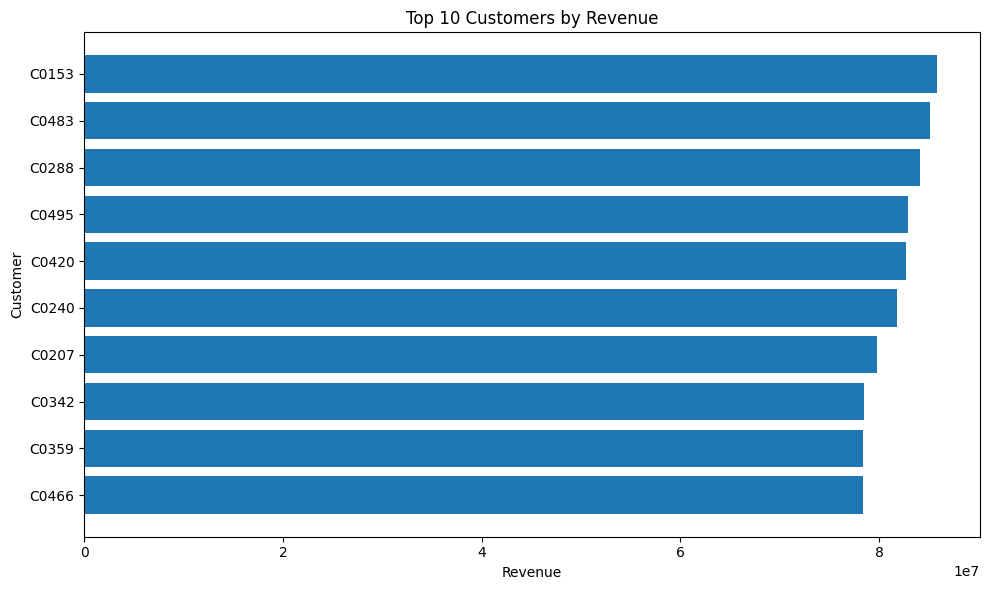

In [44]:
top10_customers = (
    customer_performance
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .head(10)
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_customers["customer_id"].astype(str),
    top10_customers["total_revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Customer")
plt.title("Top 10 Customers by Revenue")

plt.tight_layout()
plt.show()

### **Top Customers by Orders**

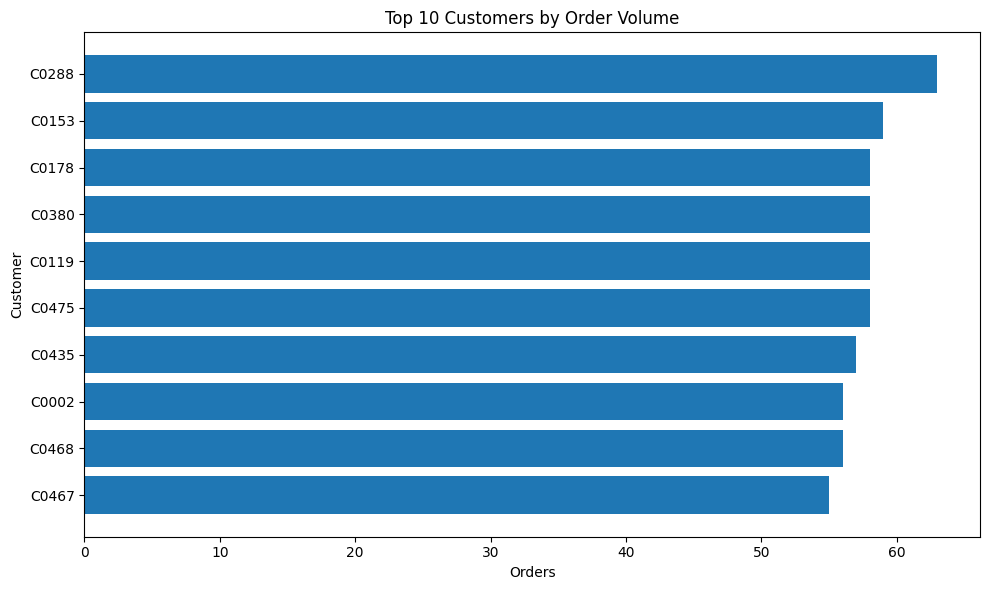

In [45]:
top10_orders = (
    customer_performance
    .sort_values(
        "total_orders",
        ascending=False
    )
    .head(10)
    .sort_values("total_orders")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_orders["customer_id"].astype(str),
    top10_orders["total_orders"]
)

plt.xlabel("Orders")
plt.ylabel("Customer")
plt.title("Top 10 Customers by Order Volume")

plt.tight_layout()
plt.show()

### **Revenue by Customer Type**

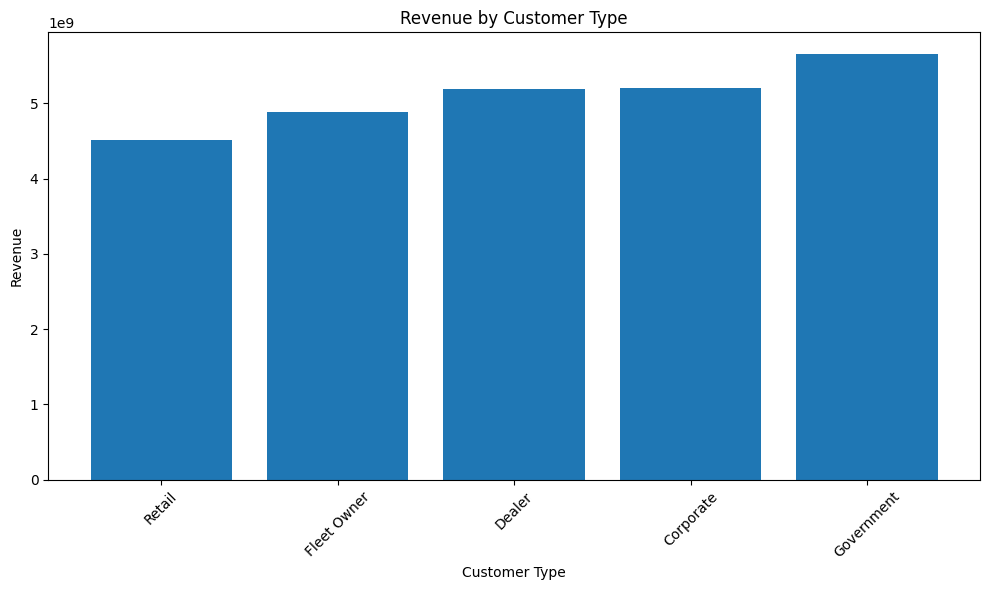

In [46]:
plot_data = customer_type_analysis.sort_values(
    "revenue"
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["customer_type"].astype(str),
    plot_data["revenue"]
)

plt.xlabel("Customer Type")
plt.ylabel("Revenue")
plt.title("Revenue by Customer Type")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Revenue by Industry Segment**

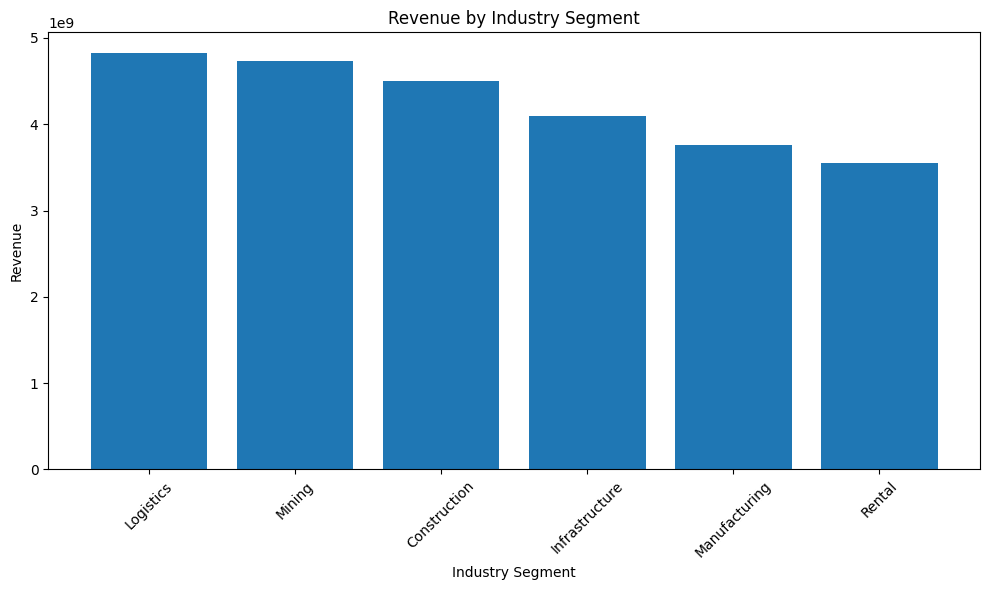

In [47]:
plot_data = industry_analysis.sort_values(
    "revenue",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["industry_segment"].astype(str),
    plot_data["revenue"]
)

plt.xlabel("Industry Segment")
plt.ylabel("Revenue")
plt.title("Revenue by Industry Segment")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Revenue by Region**

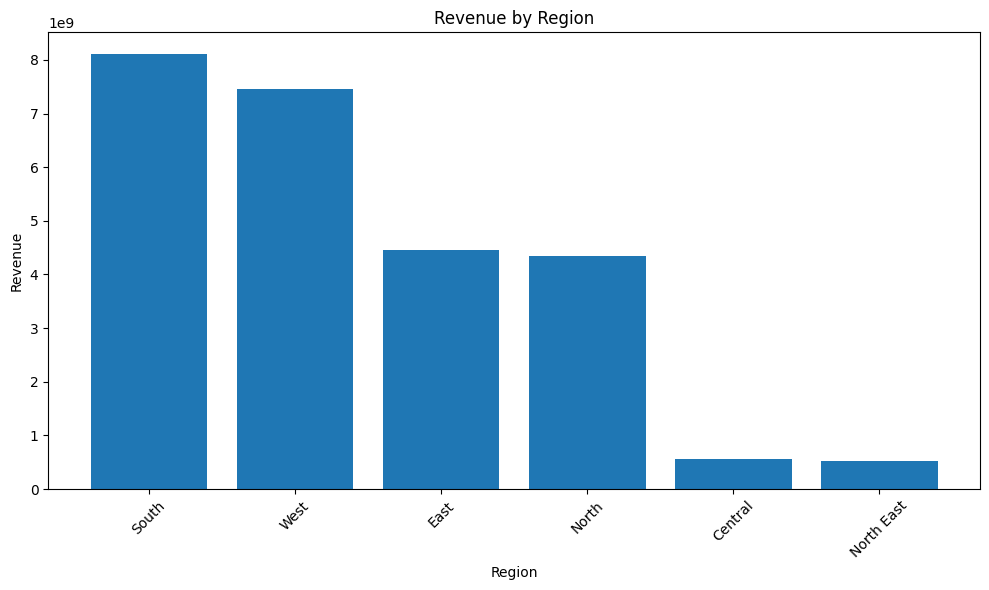

In [48]:
plot_data = region_analysis.sort_values(
    "revenue",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["region"].astype(str),
    plot_data["revenue"]
)

plt.xlabel("Region")
plt.ylabel("Revenue")
plt.title("Revenue by Region")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Revenue by Sales Channel**

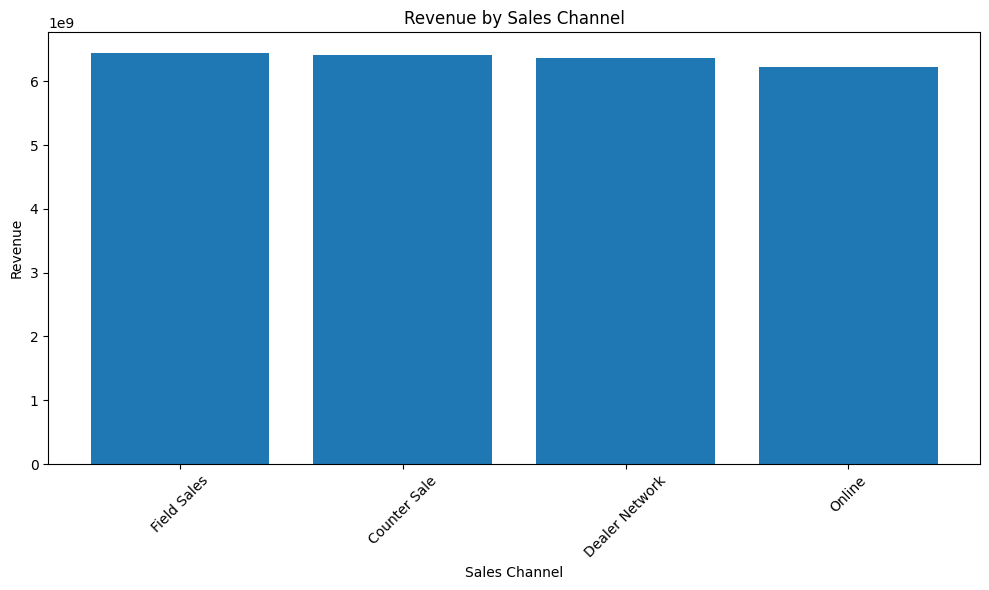

In [49]:
plot_data = channel_analysis.sort_values(
    "revenue",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["sales_channel"].astype(str),
    plot_data["revenue"]
)

plt.xlabel("Sales Channel")
plt.ylabel("Revenue")
plt.title("Revenue by Sales Channel")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Customer Performance Categories**

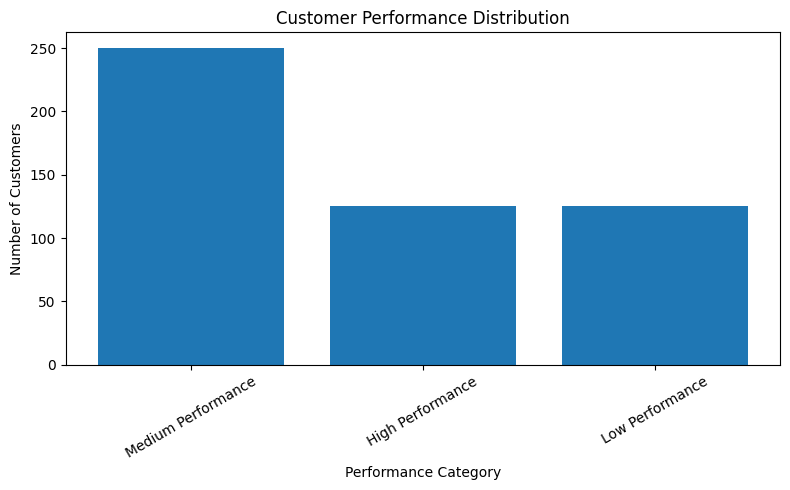

In [50]:
performance_counts = (
    customer_performance[
        "performance_category"
    ]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    performance_counts.index,
    performance_counts.values
)

plt.xlabel("Performance Category")
plt.ylabel("Number of Customers")
plt.title("Customer Performance Distribution")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### **Customer Value Categories**

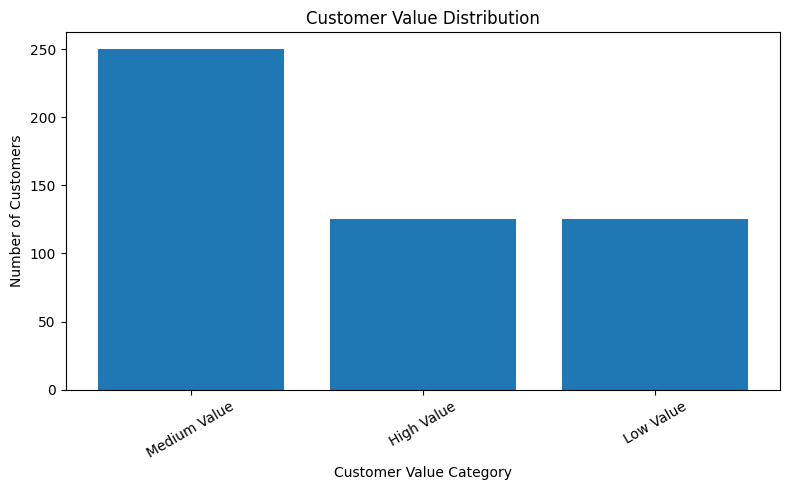

In [51]:
value_counts = (
    customer_performance[
        "customer_value_category"
    ]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    value_counts.index,
    value_counts.values
)

plt.xlabel("Customer Value Category")
plt.ylabel("Number of Customers")
plt.title("Customer Value Distribution")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### **Customer Revenue Concentration**

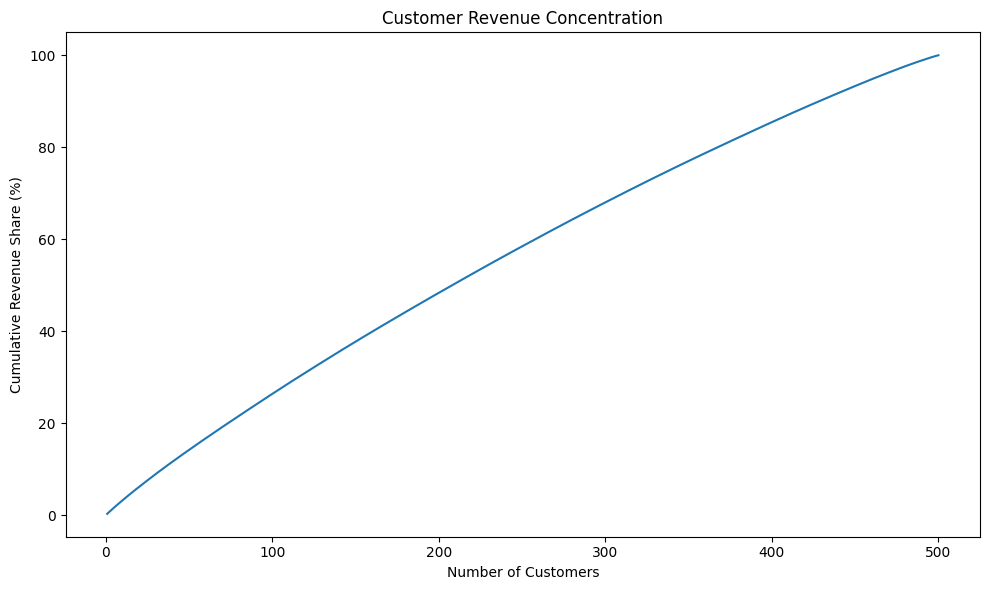

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(customer_concentration) + 1),
    customer_concentration["cumulative_revenue_share"] * 100
)

plt.xlabel("Number of Customers")
plt.ylabel("Cumulative Revenue Share (%)")
plt.title("Customer Revenue Concentration")

plt.tight_layout()
plt.show()

### **FINAL KPI CALCULATIONS**

In [53]:
week8_kpis = {
    "Total Customers": customer_performance["customer_id"].nunique(),
    "Total Orders": week8_data["so_id"].nunique(),
    "Total Units Sold": week8_data["quantity"].sum(),
    "Total Revenue": week8_data["line_total"].sum(),
    "Average Revenue per Customer": customer_performance["total_revenue"].mean(),
    "Average Orders per Customer": customer_performance["total_orders"].mean(),
    "High-Value Customers": (
        customer_performance[
            "customer_value_category"
        ].eq("High Value").sum()
    ),
    "Low-Value Customers": (
        customer_performance[
            "customer_value_category"
        ].eq("Low Value").sum()
    ),
    "Average Customer Performance Score": (
        customer_performance[
            "customer_performance_score"
        ].mean()
    ),
    "Top 10 Customer Revenue Share (%)": top_10_customer_share
}

week8_kpis

{'Total Customers': 500,
 'Total Orders': 20000,
 'Total Units Sold': np.int64(1368534),
 'Total Revenue': np.int64(25447392560),
 'Average Revenue per Customer': np.float64(50894785.12),
 'Average Orders per Customer': np.float64(40.0),
 'High-Value Customers': np.int64(125),
 'Low-Value Customers': np.int64(125),
 'Average Customer Performance Score': np.float64(60.51339583365458),
 'Top 10 Customer Revenue Share (%)': np.float64(3.2127726566575983)}

In [54]:
# KPI Table
week8_kpi_table = pd.DataFrame(
    list(week8_kpis.items()),
    columns=["KPI", "Value"]
)

week8_kpi_table

,KPI,Value
0,Total Customers,5.000000e+02
1,Total Orders,2.000000e+04
2,Total Units Sold,1.368534e+06
3,Total Revenue,2.544739e+10
4,Average Revenue per Customer,5.089479e+07
5,Average Orders per Customer,4.000000e+01
6,High-Value Customers,1.250000e+02
7,Low-Value Customers,1.250000e+02
8,Average Customer Performance Score,6.051340e+01
9,Top 10 Customer Revenue Share (%),3.212773e+00


In [55]:
formatted_kpis = week8_kpi_table.copy()

for i, row in formatted_kpis.iterrows():

    if "Revenue" in row["KPI"]:
        formatted_kpis.loc[i, "Value"] = (
            f"£{row['Value']:,.2f}"
        )

    elif "Share" in row["KPI"]:
        formatted_kpis.loc[i, "Value"] = (
            f"{row['Value']:.2f}%"
        )

    elif "Score" in row["KPI"]:
        formatted_kpis.loc[i, "Value"] = (
            f"{row['Value']:.2f}"
        )

    elif isinstance(
        row["Value"],
        (int, np.integer)
    ):
        formatted_kpis.loc[i, "Value"] = (
            f"{row['Value']:,}"
        )

formatted_kpis

/tmp/ipykernel_430/3519513588.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '£25,447,392,560.00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_kpis.loc[i, "Value"] = (


,KPI,Value
0,Total Customers,500.0
1,Total Orders,20000.0
2,Total Units Sold,1368534.0
3,Total Revenue,"£25,447,392,560.00"
4,Average Revenue per Customer,"£50,894,785.12"
5,Average Orders per Customer,40.0
6,High-Value Customers,125.0
7,Low-Value Customers,125.0
8,Average Customer Performance Score,60.51
9,Top 10 Customer Revenue Share (%),£3.21


### **EXPORT ANALYSIS FILES**

In [56]:
analysis_dir = Path("../analysis")
visual_dir = Path("../visualisations")

analysis_dir.mkdir(
    parents=True,
    exist_ok=True
)

visual_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [57]:
customer_performance.to_csv(
    analysis_dir / "customer_performance.csv",
    index=False
)

customer_type_analysis.to_csv(
    analysis_dir / "customer_type_analysis.csv",
    index=False
)

industry_analysis.to_csv(
    analysis_dir / "industry_segment_analysis.csv",
    index=False
)

region_analysis.to_csv(
    analysis_dir / "regional_sales_analysis.csv",
    index=False
)

channel_analysis.to_csv(
    analysis_dir / "sales_channel_analysis.csv",
    index=False
)

customer_concentration.to_csv(
    analysis_dir / "customer_revenue_concentration.csv",
    index=False
)

week8_kpi_table.to_csv(
    analysis_dir / "week8_customer_sales_kpis.csv",
    index=False
)

### **FINAL SUMMARY**

In [58]:
print("=" * 60)
print("WEEK 08 — CUSTOMER & SALES PERFORMANCE ANALYSIS")
print("=" * 60)

print(
    f"Total customers: "
    f"{customer_performance['customer_id'].nunique():,}"
)

print(
    f"Total orders: "
    f"{week8_data['so_id'].nunique():,}"
)

print(
    f"Total units sold: "
    f"{week8_data['quantity'].sum():,.0f}"
)

print(
    f"Total revenue: "
    f"£{week8_data['line_total'].sum():,.2f}"
)

print(
    f"Average revenue per customer: "
    f"£{customer_performance['total_revenue'].mean():,.2f}"
)

print(
    f"Average orders per customer: "
    f"{customer_performance['total_orders'].mean():.2f}"
)

print(
    f"High-value customers: "
    f"{(customer_performance['customer_value_category'] == 'High Value').sum():,}"
)

print(
    f"Low-value customers: "
    f"{(customer_performance['customer_value_category'] == 'Low Value').sum():,}"
)

print(
    f"Top 10 customer revenue share: "
    f"{top_10_customer_share:.2f}%"
)

print("=" * 60)
print("Week 08 analysis completed.")

WEEK 08 — CUSTOMER & SALES PERFORMANCE ANALYSIS
Total customers: 500
Total orders: 20,000
Total units sold: 1,368,534
Total revenue: £25,447,392,560.00
Average revenue per customer: £50,894,785.12
Average orders per customer: 40.00
High-value customers: 125
Low-value customers: 125
Top 10 customer revenue share: 3.21%
Week 08 analysis completed.
